---
title: "Time-Series Forecasting with TabPFN"
description: "Forecast univariate and multivariate time series with the TabPFN time-series pipeline."
cookbookTags:
  - time-series
  - regression
  - api
authors:
  - name: Eliott Kalfon
    linkedin: https://www.linkedin.com/in/eliott-kalfon/
---

# Time-Series Forecasting with TabPFN

*Turning the tabular foundation model into a zero-shot forecaster.*

TabPFN can forecast time series without any task-specific training. The `tabpfn-time-series` package wraps the model in a pipeline that takes historical context and returns a probabilistic forecast. This notebook covers both a univariate forecast on the M4 hourly dataset and a multivariate forecast, where known future covariates sharpen the prediction.

Reference: https://github.com/PriorLabs/tabpfn-time-series/blob/main/examples/quickstart.ipynb

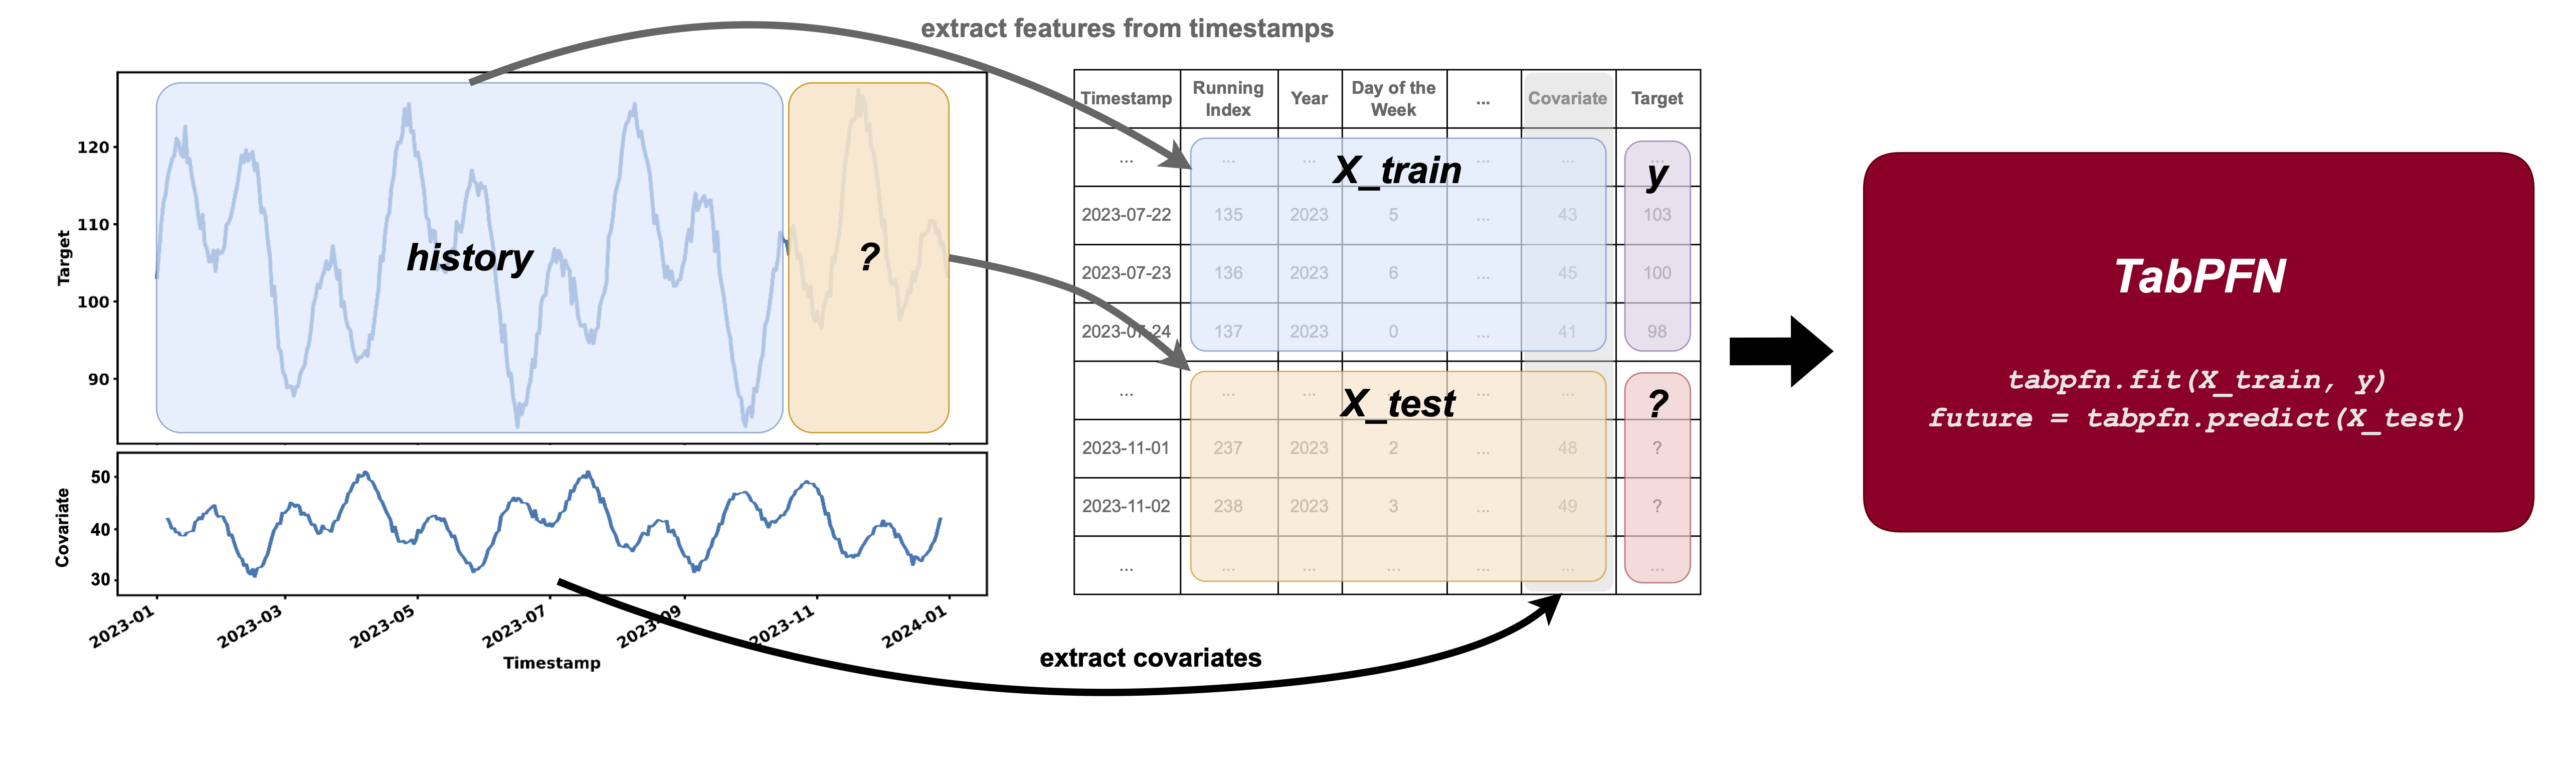

## Setup

*Installing the time-series package and authenticating.*

`tabpfn-time-series` brings the pipeline and plotting helpers. As elsewhere, the API token is read from Colab secrets.

In [1]:
!pip install scikit-learn tabpfn-time-series

In [2]:
import os

import pandas as pd

from google.colab import userdata
from tabpfn_time_series import TabPFNTSPipeline, TabPFNMode
from tabpfn_time_series.plot import plot_forecast

## Authenticating with a Token

*Setting `TABPFN_TOKEN` so the pipeline can reach the TabPFN API.*

As elsewhere, the API token is read from Colab secrets. Accept the license and copy your key from [priorlabs.ai](https://ux.priorlabs.ai) if you have not already.

In [3]:
from tabpfn_client import set_access_token
set_access_token(userdata.get('TABPFN_TOKEN'))

## Loading the Data

*The M4 hourly dataset: many hourly series with a known future to score against.*

The M4 dataset is a standard forecasting benchmark from the M4 competition; its hourly subset is a collection of many independent hourly time series (things like electricity demand or web traffic). Each individual series is one **item**, identified by an `item_id`, and we forecast each one separately. We load the standard M4 hourly train and test splits: the train frame is the historical context, and the test frame holds the actual future values we will compare the forecast against.

In [4]:
# Load M4 Hourly dataset
m4_hourly_train_url = (
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/train.csv"
)
m4_hourly_test_url = (
    "https://autogluon.s3.amazonaws.com/datasets/timeseries/m4_hourly/test.csv"
)
m4_train_df = pd.read_csv(m4_hourly_train_url, parse_dates=["timestamp"])
m4_test_df = pd.read_csv(m4_hourly_test_url, parse_dates=["timestamp"])

In [5]:
m4_train_df.head()

,item_id,timestamp,target
0,H1,1750-01-01 00:00:00,605.0
1,H1,1750-01-01 01:00:00,586.0
2,H1,1750-01-01 02:00:00,586.0
3,H1,1750-01-01 03:00:00,559.0
4,H1,1750-01-01 04:00:00,511.0


### Select a few series

*Restricting to two items to keep the demo fast and legible.*

In [6]:
selected_items = m4_train_df["item_id"].unique()[:2]
context_df = m4_train_df[m4_train_df["item_id"].isin(selected_items)].copy()
test_df = m4_test_df[m4_test_df["item_id"].isin(selected_items)].copy()

print("context_df.shape", context_df.shape)
context_df.tail()

context_df.shape (1400, 3)


,item_id,timestamp,target
1395,H2,1750-01-29 23:00:00,3705.0
1396,H2,1750-01-30 00:00:00,3652.0
1397,H2,1750-01-30 01:00:00,3460.0
1398,H2,1750-01-30 02:00:00,3248.0
1399,H2,1750-01-30 03:00:00,3105.0


### Build the pipeline

*One pipeline object drives both the univariate and multivariate forecasts.*

By default `TabPFNTSPipeline` runs TabPFN through the hosted API (`tabpfn-client`) rather than a local model. That is why the progress logs further down come from the client, and why the `TABPFN_TOKEN` set above is what authenticates those calls.

In [7]:
pipeline = TabPFNTSPipeline(tabpfn_mode=TabPFNMode.CLIENT)

## Univariate Forecast

*Forecasting from history alone, with no extra inputs.*

We ask the pipeline for a 48-step horizon. With only `context_df`, each series is forecast purely from its own past. The result is probabilistic, with quantiles around the median.

In [8]:
prediction_length = 48

pred_df = pipeline.predict_df(
    context_df=context_df,
    prediction_length=prediction_length,
)

print("pred_df.shape", pred_df.shape)
pred_df.head()

Predicting time series: 100%|██████████| 2/2 [00:00<00:00, 41.47it/s]


pred_df.shape (96, 10)


target         0.1         0.2         0.3  \
item_id timestamp                                                             
H1      1750-01-30 04:00:00  621.089050  608.086243  613.247009  616.246643   
        1750-01-30 05:00:00  554.764526  532.325439  541.405579  547.201721   
        1750-01-30 06:00:00  508.915863  476.036377  489.271973  498.152802   
        1750-01-30 07:00:00  480.749176  444.337830  457.773895  467.694153   
        1750-01-30 08:00:00  461.458160  426.360077  439.234741  449.052673   

                                    0.4         0.5         0.6         0.7  \
item_id timestamp                                                             
H1      1750-01-30 04:00:00  618.930969  621.089050  623.311768  625.763611   
        1750-01-30 05:00:00  551.278687  554.764526  558.151489  561.748901   
        1750-01-30 06:00:00  504.377045  508.915863  512.794189  516.848633   
        1750-01-30 07:00:00  475.012909  480.749176  485.107788  489.648529   
        1750-01-30 08:00:00  456.048645  461.458160  466.238739  471.229492   

                                    0.8         0.9  
item_id timestamp                                    
H1      1750-01-30 04:00:00  628.593567  632.677734  
        1750-01-30 05:00:00  566.105591  572.157654  
        1750-01-30 06:00:00  521.319580  528.396179  
        1750-01-30 07:00:00  494.574799  501.992279  
        1750-01-30 08:00:00  476.649323  483.684204

### Plotting the forecast

*The forecast against the held-out actuals.*

`plot_forecast` overlays the predicted median and quantile band on the historical context and the true future values.

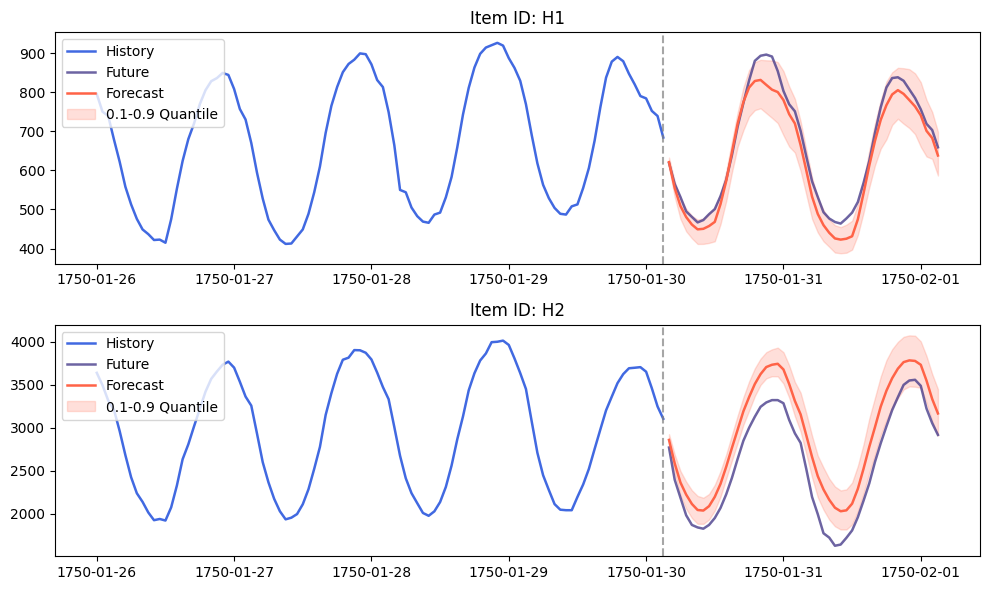

In [9]:
test_df = test_df.groupby("item_id").tail(prediction_length)
plot_forecast(context_df, pred_df, test_df=test_df, item_ids=selected_items)

## Multivariate Forecast

*Adding known future covariates to sharpen the prediction.*

Often we know something about the future: a load forecast, a weather forecast. The pipeline can condition on these covariates. Here we use an electricity-price dataset that ships with related forecasts, and compare predictions with and without them.

### Load the data

*The electricity-price dataset, with covariate columns alongside the target.*

In [10]:
# Load Electricity Price dataset
train_url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/train.parquet"
test_url = "https://autogluon.s3.amazonaws.com/datasets/timeseries/electricity_price/test.parquet"

elec_train_df = pd.read_parquet(train_url)
elec_test_df = pd.read_parquet(test_url)

print(f"Train shape: {elec_train_df.shape}")
print(f"Test shape: {elec_test_df.shape}")
print(f"\nColumns: {elec_train_df.columns.tolist()}")
elec_train_df.head()

Train shape: (51936, 5)
Test shape: (24, 5)

Columns: ['id', 'timestamp', 'target', 'Ampirion Load Forecast', 'PV+Wind Forecast']


,id,timestamp,target,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2012-01-09 00:00:00,34.970001,16382.00,3569.527588
1,DE,2012-01-09 01:00:00,33.430000,15410.50,3315.274902
2,DE,2012-01-09 02:00:00,32.740002,15595.00,3107.307617
3,DE,2012-01-09 03:00:00,32.459999,16521.00,2944.620117
4,DE,2012-01-09 04:00:00,32.500000,17700.75,2897.149902


### Prepare the data

*Renaming to the expected schema and isolating a single region.*

The pipeline expects `timestamp`, `target`, an optional `item_id`, and any covariate columns. We rename accordingly, pick one region, and split the covariates into a `future_df` that excludes the target.

In [11]:
# Rename columns to match expected format
# The pipeline expects: timestamp, target, item_id (optional), and any covariate columns
elec_train_df = elec_train_df.rename(columns={"id": "item_id"})
elec_test_df = elec_test_df.rename(columns={"id": "item_id"})
covariate_cols = ["Ampirion Load Forecast", "PV+Wind Forecast"]

# Select a single region for demonstration.
# You can pass multiple item_ids here as long as future_df contains each item's horizon covariates.
selected_region = elec_train_df["item_id"].unique()[0]
context_df = elec_train_df[elec_train_df["item_id"] == selected_region].copy()
test_df = elec_test_df[elec_test_df["item_id"] == selected_region].copy()

print(f"Region: {selected_region}")
print(f"Context length: {len(context_df)}")
print(f"Test length: {len(test_df)}")

Region: DE
Context length: 51936
Test length: 24


In [12]:
future_df = test_df.drop(columns=["target"])

print("Future covariates:")
future_df.head()

Future covariates:


,item_id,timestamp,Ampirion Load Forecast,PV+Wind Forecast
0,DE,2017-12-12 00:00:00,20483.00,22284.005859
1,DE,2017-12-12 01:00:00,19849.75,22878.673828
2,DE,2017-12-12 02:00:00,19638.25,23632.283203
3,DE,2017-12-12 03:00:00,19895.25,24635.945312
4,DE,2017-12-12 04:00:00,20338.00,25584.935547


### Predict with and without covariates

*Two forecasts from the same history, differing only in the covariates.*

Running the pipeline twice, once including the covariate columns and once dropping them, isolates exactly how much the extra information helps.

In [13]:
pred_w_covariates_df = pipeline.predict_df(
    context_df=context_df,
    future_df=future_df,
)
pred_without_covariates_df = pipeline.predict_df(
    context_df=context_df.drop(columns=covariate_cols),
    future_df=future_df.drop(columns=covariate_cols),
)

Predicting time series:   0%|          | 0/1 [00:00<?, ?it/s]

00:00 Fitting... \

00:00 Fitting... Done!
00:00 Predicting... \

00:04 Predicting... Done!


Predicting time series:   0%|          | 0/1 [00:00<?, ?it/s]

00:00 Fitting... \

00:00 Fitting... Done!
00:00 Predicting... \

00:04 Predicting... Done!


Predicting time series: 100%|██████████| 1/1 [00:05<00:00,  5.51s/it]


## Comparing the Forecasts

*Side by side: does knowing the future help?*

### Without covariates

*History only.*

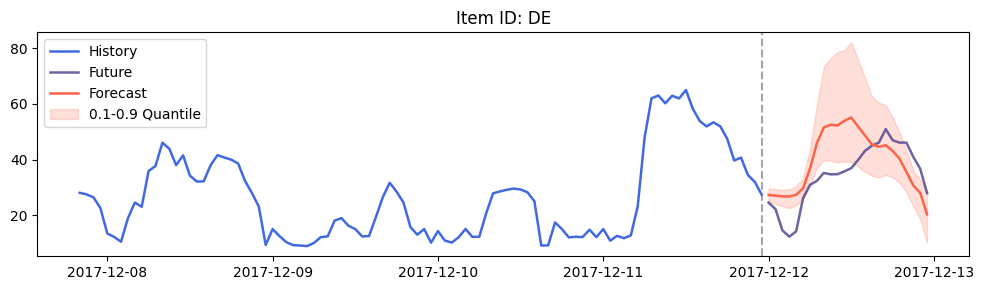

In [14]:
plot_forecast(
    context_df, pred_without_covariates_df, test_df=test_df, item_ids=[selected_region]
)

### With covariates

*The same horizon, now conditioned on the known future inputs.*

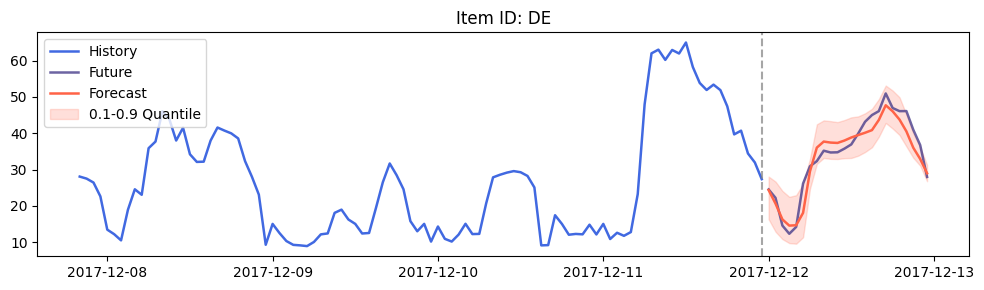

In [15]:
plot_forecast(
    context_df, pred_w_covariates_df, test_df=test_df, item_ids=[selected_region]
)